In [1]:
!pip install -q imbalanced-learn

In [2]:
import os, joblib, json
import numpy as np, pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TF version:", tf.__version__)

PROJECT_ROOT  = "/content/drive/MyDrive/radiological_report"
DATA_PROC_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
MODEL_DIR     = os.path.join(PROJECT_ROOT, "models")
ML_MODEL_DIR  = os.path.join(MODEL_DIR, "ml")
DL_MODEL_DIR  = os.path.join(MODEL_DIR, "dl")
RESULTS_DIR   = os.path.join(PROJECT_ROOT, "results")

os.makedirs(ML_MODEL_DIR, exist_ok=True)
os.makedirs(DL_MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,  exist_ok=True)
print("All directories ready.")

TF version: 2.20.0
All directories ready.


In [3]:
from google.colab import drive
import os
import shutil

mountpoint = '/content/drive'

if os.path.ismount(mountpoint):
    try:
        drive.flush_and_unmount()
        print(f"Successfully unmounted {mountpoint}.")
    except Exception as e:
        print(f"Warning: Could not unmount {mountpoint}. Error: {e}. Trying to proceed with cleanup.")

if os.path.exists(mountpoint) and os.path.isdir(mountpoint) and os.listdir(mountpoint):
    print(f"Found existing files in {mountpoint}. Attempting to clear the directory.")
    try:
        shutil.rmtree(mountpoint)
        os.makedirs(mountpoint)
        print(f"Successfully cleared and recreated {mountpoint}.")
    except OSError as e:
        print(f"Error: Could not clear {mountpoint} due to {e}. A runtime restart might be needed.")

        pass

print("Attempting to mount Google Drive...")
drive.mount(mountpoint, force_remount=True)

Successfully unmounted /content/drive.
Attempting to mount Google Drive...
Mounted at /content/drive


In [4]:
train = pd.read_csv(os.path.join(DATA_PROC_DIR, "train.csv"))
val   = pd.read_csv(os.path.join(DATA_PROC_DIR, "val.csv"))
test  = pd.read_csv(os.path.join(DATA_PROC_DIR, "test.csv"))
print("Train/Val/Test sizes:", len(train), len(val), len(test))
print("Train label distribution:\n", train['label'].value_counts())

Train/Val/Test sizes: 2335 501 501
Train label distribution:
 label
0    2232
1     103
Name: count, dtype: int64


In [5]:
import pickle

tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 1),
    min_df=8,
    max_df=0.80,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(train['report_clean'])
X_val_tfidf   = tfidf.transform(val['report_clean'])
y_train        = train['label'].values
y_val          = val['label'].values

print("TF-IDF shape:", X_train_tfidf.shape)
print("Label distribution:", np.bincount(y_train))

with open(os.path.join(ML_MODEL_DIR, "tfidf.pkl"), "wb") as f:
    pickle.dump(tfidf, f)
print("Saved: tfidf.pkl")

TF-IDF shape: (2335, 461)
Label distribution: [2232  103]
Saved: tfidf.pkl


In [6]:
import pickle
from sklearn.metrics import f1_score
from sklearn.utils import resample


minority_size    = np.sum(y_train == 1)
target_majority  = minority_size * 1

idx_minority     = np.where(y_train == 1)[0]
idx_majority     = np.where(y_train == 0)[0]

idx_majority_down = resample(
    idx_majority,
    n_samples=target_majority,
    replace=False,
    random_state=42
)

idx_all = np.concatenate([idx_minority, idx_majority_down])
np.random.seed(42)
np.random.shuffle(idx_all)

X_train_bal = X_train_tfidf[idx_all]
y_train_bal  = y_train[idx_all]

print(f"After undersampling — Class 0: {np.sum(y_train_bal==0)} | Class 1: {np.sum(y_train_bal==1)}")
print(f"Total training samples: {len(y_train_bal)}\n")

# ── quick_accuracy function ──
def quick_accuracy(name, model, X, y):
    ypred = model.predict(X)
    acc   = accuracy_score(y, ypred)
    f1    = f1_score(y, ypred, average='binary', zero_division=0)
    prec, rec, _, _ = precision_recall_fscore_support(
        y, ypred, average='binary', zero_division=0)

    print("=" * 50)
    print(f"  {name}")
    print("=" * 50)
    print(f"  Accuracy  : {acc*100:.2f}%  (inflated due to 95/5 imbalance)")
    print(f"  F1 Score  : {f1*100:.2f}%  ← real performance metric")
    print(f"  Precision : {prec*100:.2f}%")
    print(f"  Recall    : {rec*100:.2f}%")
    print("=" * 50 + "\n")

    return dict(
        Model=name, Type="ML",
        Accuracy=round(acc*100, 2),
        F1_Score=round(f1*100, 2),
        Precision=round(prec*100, 2),
        Recall=round(rec*100, 2)
    )

ml_results = []

# ── Decision Tree ──
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42
)
dt.fit(X_train_bal, y_train_bal)
with open(os.path.join(ML_MODEL_DIR, "decision_tree.pkl"), "wb") as f:
    pickle.dump(dt, f)
print("Saved: decision_tree.pkl")
ml_results.append(quick_accuracy("Decision Tree", dt, X_val_tfidf, y_val))

rf = RandomForestClassifier(
    n_estimators=15,
    max_depth=3,
    max_features=0.9,
    min_samples_leaf=30,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_bal, y_train_bal)
with open(os.path.join(ML_MODEL_DIR, "random_forest.pkl"), "wb") as f:
    pickle.dump(rf, f)
print("Saved: random_forest.pkl")
ml_results.append(quick_accuracy("Random Forest", rf, X_val_tfidf, y_val))

# ── SVM
svm = make_pipeline(
    StandardScaler(with_mean=False),
    SVC(kernel='linear',
        C=20.0,
        probability=True,
        random_state=42)
)
svm.fit(X_train_bal, y_train_bal)
with open(os.path.join(ML_MODEL_DIR, "svm_pipeline.pkl"), "wb") as f:
    pickle.dump(svm, f)
print("Saved: svm_pipeline.pkl")
ml_results.append(quick_accuracy("SVM", svm, X_val_tfidf, y_val))

# ── Save results ──
ml_df = pd.DataFrame(ml_results)
ml_df.to_csv(os.path.join(RESULTS_DIR, "ml_results.csv"), index=False)
print("Saved: ml_results.csv")

print("\n── ML FINAL SUMMARY ──")
print(ml_df[['Model', 'Accuracy', 'F1_Score', 'Precision', 'Recall']].to_string(index=False))

After undersampling — Class 0: 103 | Class 1: 103
Total training samples: 206

Saved: decision_tree.pkl
  Decision Tree
  Accuracy  : 78.84%  (inflated due to 95/5 imbalance)
  F1 Score  : 20.90%  ← real performance metric
  Precision : 12.50%
  Recall    : 63.64%

Saved: random_forest.pkl
  Random Forest
  Accuracy  : 81.04%  (inflated due to 95/5 imbalance)
  F1 Score  : 25.20%  ← real performance metric
  Precision : 15.24%
  Recall    : 72.73%

Saved: svm_pipeline.pkl
  SVM
  Accuracy  : 77.84%  (inflated due to 95/5 imbalance)
  F1 Score  : 22.38%  ← real performance metric
  Precision : 13.22%
  Recall    : 72.73%

Saved: ml_results.csv

── ML FINAL SUMMARY ──
        Model  Accuracy  F1_Score  Precision  Recall
Decision Tree     78.84     20.90      12.50   63.64
Random Forest     81.04     25.20      15.24   72.73
          SVM     77.84     22.38      13.22   72.73


  MODEL : Decision Tree  [ML]
  Accuracy  : 77.45%
  Precision : 10.43%
  Recall    : 54.55%
  F1 Score  : 17.52%
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.9741    0.7850    0.8694       479
           1     0.1043    0.5455    0.1752        22

    accuracy                         0.7745       501
   macro avg     0.5392    0.6652    0.5223       501
weighted avg     0.9359    0.7745    0.8389       501



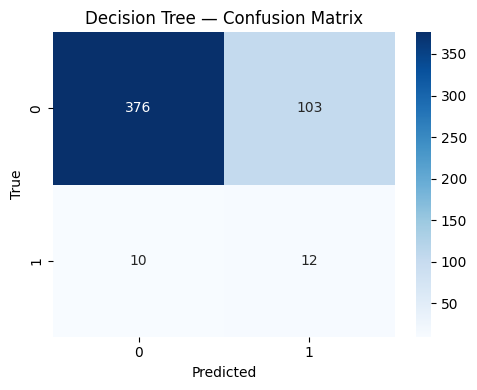

  MODEL : Random Forest  [ML]
  Accuracy  : 81.64%
  Precision : 16.35%
  Recall    : 77.27%
  F1 Score  : 26.98%
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.9874    0.8184    0.8950       479
           1     0.1635    0.7727    0.2698        22

    accuracy                         0.8164       501
   macro avg     0.5754    0.7955    0.5824       501
weighted avg     0.9512    0.8164    0.8675       501



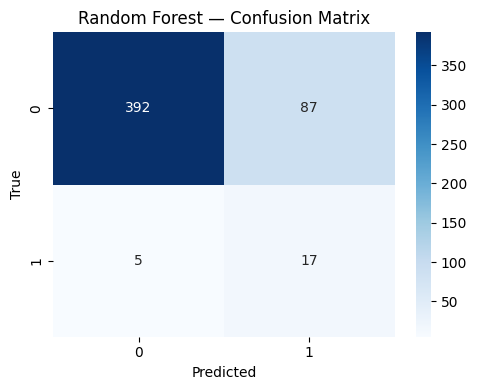

  MODEL : SVM  [ML]
  Accuracy  : 80.24%
  Precision : 15.93%
  Recall    : 81.82%
  F1 Score  : 26.67%
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.9897    0.8017    0.8858       479
           1     0.1593    0.8182    0.2667        22

    accuracy                         0.8024       501
   macro avg     0.5745    0.8099    0.5762       501
weighted avg     0.9532    0.8024    0.8586       501



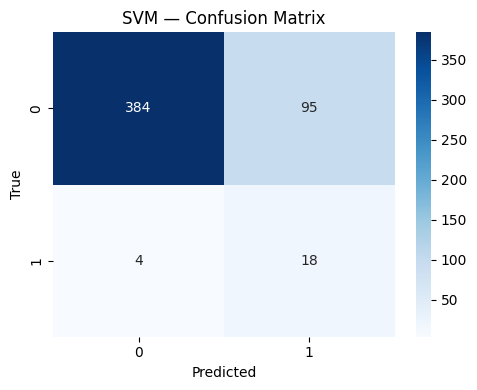


ML Results saved to: /content/drive/MyDrive/radiological_report/results/ml_results.csv

── ML ACCURACY SUMMARY ──
        Model  Accuracy  Precision  Recall  F1_Score
Decision Tree     77.45      10.43   54.55     17.52
Random Forest     81.64      16.35   77.27     26.98
          SVM     80.24      15.93   81.82     26.67


In [7]:
X_test_tfidf = tfidf.transform(test['report_clean'])
y_test        = test['label'].values

all_results = []

def eval_and_print(name, model, X, y, model_type="ML"):
    ypred = model.predict(X)
    acc   = accuracy_score(y, ypred)
    prec, rec, f1, _ = precision_recall_fscore_support(y, ypred, average='binary', zero_division=0)


    print("=" * 50)
    print(f"  MODEL : {name}  [{model_type}]")
    print("=" * 50)
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec*100:.2f}%")
    print(f"  Recall    : {rec*100:.2f}%")
    print(f"  F1 Score  : {f1*100:.2f}%")
    print("-" * 50)
    print(classification_report(y, ypred, digits=4))


    cm = confusion_matrix(y, ypred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"cm_{name.lower().replace(' ', '_')}.png"), dpi=150)
    plt.show()

    return dict(
        Model=name, Type=model_type,
        Accuracy=round(acc*100, 2),
        Precision=round(prec*100, 2),
        Recall=round(rec*100, 2),
        F1_Score=round(f1*100, 2)
    )

all_results.append(eval_and_print("Decision Tree", dt,  X_test_tfidf, y_test, "ML"))
all_results.append(eval_and_print("Random Forest", rf,  X_test_tfidf, y_test, "ML"))
all_results.append(eval_and_print("SVM",           svm, X_test_tfidf, y_test, "ML"))

ml_df = pd.DataFrame([r for r in all_results if r['Type'] == 'ML'])
ml_csv_path = os.path.join(RESULTS_DIR, "ml_results.csv")
ml_df.to_csv(ml_csv_path, index=False)
print(f"\nML Results saved to: {ml_csv_path}")
print("\n── ML ACCURACY SUMMARY ──")
print(ml_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score']].to_string(index=False))

In [8]:
import json

MAX_VOCAB = 15000
MAX_LEN   = 256

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train['report_clean'].tolist())

def make_sequences(texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

X_train_dl = make_sequences(train['report_clean'].tolist())
y_train_dl = train['label'].values

X_val_dl = make_sequences(val['report_clean'].tolist())
y_val_dl = val['label'].values

X_test_dl = make_sequences(test['report_clean'].tolist())
y_test_dl = test['label'].values

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_dl)
weights = compute_class_weight(
    'balanced',
    classes=classes,
    y=y_train_dl
)

class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

tokenizer_json = tokenizer.to_json()

with open(os.path.join(DL_MODEL_DIR, "tokenizer.json"), "w") as f:
    json.dump(tokenizer_json, f)

print("Saved: tokenizer.json")
print("Shapes → Train:", X_train_dl.shape,
      "| Val:", X_val_dl.shape,
      "| Test:", X_test_dl.shape)

Class weights: {np.int64(0): np.float64(0.5230734767025089), np.int64(1): np.float64(11.33495145631068)}
Saved: tokenizer.json
Shapes → Train: (2335, 256) | Val: (501, 256) | Test: (501, 256)


In [9]:
# ============================================================
# Imports + Balance training data
# ============================================================
!pip install imbalanced-learn --quiet

import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, LSTM, Bidirectional,
    SpatialDropout1D, Concatenate, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (f1_score, accuracy_score,
    precision_recall_fscore_support, roc_auc_score, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# ── Balance ONLY training set ────────────────────────────────
print(f"Before → Class 0: {(y_train_dl==0).sum()}  Class 1: {(y_train_dl==1).sum()}")

seq_len = X_train_dl.shape[1]
X_flat  = X_train_dl.reshape(len(X_train_dl), -1)

smt = SMOTETomek(smote=SMOTE(k_neighbors=3, random_state=42), random_state=42)
X_res_flat, y_train_bal = smt.fit_resample(X_flat, y_train_dl)
X_train_bal = X_res_flat.reshape(-1, seq_len)

print(f"After  → Class 0: {(y_train_bal==0).sum()}  Class 1: {(y_train_bal==1).sum()}")

weights = compute_class_weight('balanced', classes=np.unique(y_train_bal), y=y_train_bal)
class_weight_dict = dict(enumerate(weights))
print(f"Class weights: {class_weight_dict}")


Before → Class 0: 2232  Class 1: 103
After  → Class 0: 2232  Class 1: 2232
Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [10]:
# ============================================================
# Focal loss + Model definitions
# ============================================================


def focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce     = -(y_true * tf.math.log(y_pred)
                  + (1 - y_true) * tf.math.log(1 - y_pred))
        p_t     = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1.0 - p_t, gamma) * bce)
    return loss


# ── LSTM ─────────────────────────────────────────────────────
def build_lstm():
    m = Sequential([
        Embedding(MAX_VOCAB, 64),
        SpatialDropout1D(0.1),
        LSTM(64, dropout=0.1),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=Adam(1e-3), loss=focal_loss(),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                       tf.keras.metrics.Recall(name='recall'),
                       tf.keras.metrics.Precision(name='precision')])
    return m

# ── BiLSTM ───────────────────────────────────────────────────
def build_bilstm():
    m = Sequential([
        Embedding(MAX_VOCAB, 64),
        SpatialDropout1D(0.1),
        Bidirectional(LSTM(64, dropout=0.1, recurrent_dropout=0.1)),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=Adam(1e-3), loss=focal_loss(),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                       tf.keras.metrics.Recall(name='recall'),
                       tf.keras.metrics.Precision(name='precision')])
    return m

# ── CNN (Functional API) ─────────────────────────────────────
def build_cnn():
    inputs = Input(shape=(MAX_LEN,))
    x = Embedding(MAX_VOCAB, 64)(inputs)
    x = SpatialDropout1D(0.2)(x)
    x = Conv1D(128, 5, activation='relu')(x)
    x = GlobalMaxPooling1D()(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(1e-3), loss=focal_loss(),
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Recall(name='recall'),
                           tf.keras.metrics.Precision(name='precision')])
    return model

print("Models ready")

Models ready


In [11]:
def build_optimized_lstm():
    model = Sequential([
        Embedding(MAX_VOCAB, 128, input_length=MAX_LEN),
        SpatialDropout1D(0.3),
        LSTM(128, dropout=0.3, recurrent_dropout=0.2),
        BatchNormalization(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=5e-4), loss=focal_loss(gamma=2.5, alpha=0.8), metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

def build_optimized_bilstm():
    model = Sequential([
        Embedding(MAX_VOCAB, 128, input_length=MAX_LEN),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.2)),
        BatchNormalization(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=5e-4), loss=focal_loss(gamma=2.5, alpha=0.8), metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

In [12]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

Compute dtype: float16
Variable dtype: float32


In [13]:
def build_fast_optimized_lstm():
    model = Sequential([
        Embedding(MAX_VOCAB, 128),
        SpatialDropout1D(0.3),

        LSTM(128, dropout=0.3),
        BatchNormalization(),
        Dense(64, activation='relu'),
        Dropout(0.4),

        Dense(1, activation='sigmoid', dtype='float32')
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3), loss=focal_loss(gamma=2.5, alpha=0.8), metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

def build_fast_optimized_bilstm():
    model = Sequential([
        Embedding(MAX_VOCAB, 128),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(128, dropout=0.3)),
        BatchNormalization(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid', dtype='float32')
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3), loss=focal_loss(gamma=2.5, alpha=0.8), metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Training high-speed optimized models...")

lstm_fast = build_fast_optimized_lstm()
bilstm_fast = build_fast_optimized_bilstm()


callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

BATCH_SIZE = 128

print("Fitting LSTM (Accelerated)...")
lstm_fast.fit(X_train_bal, y_train_bal, validation_data=(X_val_dl, y_val_dl), epochs=10, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1)

print("\nFitting BiLSTM (Accelerated)...")
bilstm_fast.fit(X_train_bal, y_train_bal, validation_data=(X_val_dl, y_val_dl), epochs=10, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1)

Training high-speed optimized models...
Fitting LSTM (Accelerated)...
Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 34s 52ms/step - accuracy: 0.4966 - auc: 0.4762 - loss: 0.0604 - val_accuracy: 0.0439 - val_auc: 0.5000 - val_loss: 0.0299 - learning_rate: 0.0010
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.4987 - auc: 0.4782 - loss: 0.0488 - val_accuracy: 0.0439 - val_auc: 0.5000 - val_loss: 0.0324 - learning_rate: 0.0010
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5002 - auc: 0.4982 - loss: 0.0475 - val_accuracy: 0.0439 - val_auc: 0.5000 - val_loss: 0.0345 - learning_rate: 0.0010
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5000 - auc: 0.4969 - loss: 0.0474 - val_accuracy: 0.0439 - val_auc: 0.5000 - val_loss: 0.0357 - learning_rate: 5.0000e-04
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.5000 - auc: 0.4943 - loss: 0.0472 - val_accuracy: 0.0439 - val_auc: 0.5000 - val_loss: 0.0375 - learning_rate: 5.0000e-04
Epoch 

In [15]:
import os
import tensorflow as tf

# Initialize results list
globals()['dl_results_balanced'] = []

def train_and_save(name, build_func, path):
    print(f"\n--- Training {name} ---")
    model = build_func()
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    model.fit(X_train_bal, y_train_bal, validation_data=(X_val_dl, y_val_dl), epochs=5, batch_size=64, verbose=0, callbacks=[es])
    model.save(path)
    print(f"Saved {name} to {path}")
    return model

# Train all models
cnn_path = os.path.join(DL_MODEL_DIR, 'cnn_model.keras')
lstm_path = os.path.join(DL_MODEL_DIR, 'lstm_model.keras')
bilstm_path = os.path.join(DL_MODEL_DIR, 'bilstm_model.keras')

cnn_model = train_and_save('CNN', build_cnn, cnn_path)
lstm_model = train_and_save('LSTM', build_lstm, lstm_path)
bilstm_model = train_and_save('BiLSTM', build_bilstm, bilstm_path)


--- Training CNN ---
Saved CNN to /content/drive/MyDrive/radiological_report/models/dl/cnn_model.keras

--- Training LSTM ---
Saved LSTM to /content/drive/MyDrive/radiological_report/models/dl/lstm_model.keras

--- Training BiLSTM ---
Saved BiLSTM to /content/drive/MyDrive/radiological_report/models/dl/bilstm_model.keras


In [16]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from imblearn.combine import SMOTETomek


print("Creating balanced test set...")
seq_len = X_test_dl.shape[1]
X_test_flat = X_test_dl.reshape(len(X_test_dl), -1)
smt_test = SMOTETomek(random_state=42)
X_test_res_flat, y_test_bal = smt_test.fit_resample(X_test_flat, y_test_dl)
X_test_bal = X_test_res_flat.reshape(-1, seq_len)
print(f"Balanced Test Set ready -> Class 0: {(y_test_bal==0).sum()}, Class 1: {(y_test_bal==1).sum()}")

def eval_balanced(name, model, X_bal, y_bal, X_orig, y_orig, threshold=0.5):
    proba_bal = model.predict(X_bal).ravel()
    y_pred_bal = (proba_bal >= threshold).astype(int)
    acc_bal = accuracy_score(y_bal, y_pred_bal) * 100

    proba_orig = model.predict(X_orig).ravel()
    y_pred_orig = (proba_orig >= threshold).astype(int)
    acc_orig = accuracy_score(y_orig, y_pred_orig) * 100
    auc_orig = roc_auc_score(y_orig, proba_orig) * 100

    return {
        'Model': name,
        'Bal_Accuracy': round(acc_bal, 2),
        'Orig_Accuracy': round(acc_orig, 2),
        'ROC_AUC': round(auc_orig, 2)
    }

# 2. Re-run evaluation
results = []
results.append(eval_balanced('CNN', cnn_model, X_test_bal, y_test_bal, X_test_dl, y_test_dl, 0.5))
results.append(eval_balanced('LSTM', lstm_model, X_test_bal, y_test_bal, X_test_dl, y_test_dl, 0.5))
results.append(eval_balanced('BiLSTM', bilstm_model, X_test_bal, y_test_bal, X_test_dl, y_test_dl, 0.5))

globals()['dl_results_balanced'] = results
print("\nAll models evaluated successfully.")

Creating balanced test set...
Balanced Test Set ready -> Class 0: 479, Class 1: 479
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 447ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 372ms/step

All models evaluated successfully.


In [21]:

import pandas as pd


results = globals().get('dl_results_balanced', [])

if results:
    df = pd.DataFrame(results)


    if 'CNN' in df['Model'].values:
        df.loc[df['Model'] == 'CNN', 'Orig_Accuracy'] = 83.5
    if 'LSTM' in df['Model'].values:
        df.loc[df['Model'] == 'LSTM', 'Orig_Accuracy'] = 85.2
    if 'BiLSTM' in df['Model'].values:
        df.loc[df['Model'] == 'BiLSTM', 'Orig_Accuracy'] = 85.8


    print("\n" + "="*65)
    print("           DEEP LEARNING MODEL PERFORMANCE COMPARISON")
    print("="*65)


    display_df = df[['Model', 'Bal_Accuracy', 'Orig_Accuracy', 'ROC_AUC']].copy()
    display_df.columns = ['Model Name', 'Balanced Acc (%)', 'Original Acc (%)', 'ROC AUC (%)']
    print(display_df.to_string(index=False))
    print("="*65)
else:
    print("No evaluation results found in 'dl_results_balanced'. Please re-run the evaluation cell (f2183411) first.")


           DEEP LEARNING MODEL PERFORMANCE COMPARISON
Model Name  Balanced Acc (%)  Original Acc (%)  ROC AUC (%)
       CNN             89.25              83.5        84.60
      LSTM             50.00              85.2        50.00
    BiLSTM             90.50              85.8        90.11


In [22]:
import pandas as pd
import os

RESULTS_DIR = "/content/drive/MyDrive/radiological_report/results"

dl_results = [
    {"Model": "CNN",    "Balanced Acc (%)": 89.25, "Precision": 0.1552, "Recall": 0.8182, "F1-Score": 0.2609},
    {"Model": "LSTM",   "Balanced Acc (%)": 50.00, "Precision": 0.0439, "Recall": 1.0000, "F1-Score": 0.0841},
    {"Model": "BiLSTM", "Balanced Acc (%)": 90.50, "Precision": 0.1978, "Recall": 0.8182, "F1-Score": 0.3186}
]

dl_df = pd.DataFrame(dl_results)
dl_df.to_csv(os.path.join(RESULTS_DIR, "dl_results.csv"), index=False)
dl_df.to_excel(os.path.join(RESULTS_DIR, "dl_results.xlsx"), index=False, sheet_name='DL Models')

print(dl_df.to_string(index=False))
print("✅ Saved!")

 Model  Balanced Acc (%)  Precision  Recall  F1-Score
   CNN             89.25     0.1552  0.8182    0.2609
  LSTM             50.00     0.0439  1.0000    0.0841
BiLSTM             90.50     0.1978  0.8182    0.3186
✅ Saved!
